# Segment Anything Model (SAM)

The Segment Anything Model is a groundbreaking image segmentation model developed by Meta AI, designed to revolutionaise the field of Computer Vision. SAM introduces a novel approach to image segmentation by allowing users to generate segmentation masks using various prompt, such as spatial clues or text inputs. This model is trained on the vast SA-1B dataset, which includes over 1 billion segmentation masks across 11 million images, enabling SAM to perform zer-shot segmentation with remarkable accuracy and versatility. 

SAM's architecture consists of:
- An image encoder
- A prompt encoder
- Lightweight mask decoder

This makes it adaptable to diverse tasks without the need for extensive retraining of custom data annotation. This capability positions SAM as a powerful tool for various applications, including content creation, scientific research, and augmented reality, where precise image segmentation is crucial. 

## Prompting Technique

SAM can take prompts from users about which area to segment out precisely. As of the current release, users can provide three different prompts to SAM:
- By clicking on a point
- By drawing a bounding box
- By drawing a rough mask on an object

<img src="https://learnopencv.com/wp-content/uploads/2023/04/segment-anything-promptable-segmentation.png">


In [7]:
import zipfile
import requests
import numpy as np
from pathlib import Path

import cv2
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from transformers import TFSamModel, SamProcessor
import tensorflow_hub as hub
from tensorflow.python.ops.numpy_ops import np_config

## Download dataset

In [4]:
def download_file(url: str, save_file_path: Path):
    file = requests.get(url)
    open(save_file_path, "wb").write(file.content)


def unzip(zip_file_path: Path):
    try:
        with zipfile.ZipFile(zip_file_path) as z:
            z.extractall("./")
            print("Extracted all")
    except:
        print("Invalid file")


PARENT = Path().resolve()
DATASET = PARENT / "sam_infer_input.zip"

if not DATASET.exists():
    download_file(
        url="https://www.dropbox.com/scl/fi/301ah7zj4iolt9e4x0y2x/sam_infer_input.zip?rlkey=p9ktqv6y70kbbidfsgs75qh9p&st=vrwd09cw&dl=1",
        save_file_path=DATASET,
    )

    unzip(zip_file_path=DATASET)

Extracted all


## Load SAM Model

In [6]:
model = TFSamModel.from_pretrained("facebook/sam-vit-base", use_safetensors=False)
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

All model checkpoint layers were used when initializing TFSamModel.

All the layers of TFSamModel were initialized from the model checkpoint at facebook/sam-vit-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSamModel for predictions without further training.


## Helper Functions

In [8]:
np_config.enable_numpy_behavior()


def show_mask(mask, ax, random_colour=False):
    if random_colour:
        colour = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        colour = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])

    height, weight = mask.shape[-2:]
    mask_image = mask.reshape(height, weight, 1) * colour.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    width, height = box[2] - box[0], box[3] - box[1]

    ax.add_patch(
        plt.Rectangle(
            (x0, y0), width, height, edgecolor="green", facecolor=(0, 0, 0, 0), lw=2
        )
    )


def show_boxes_on_image(raw_image, boxes):
    plt.figure(figsize=(10, 10))
    plt.imshow(raw_image)
    for box in boxes:
        show_box(box, plt.gca())
    plt.axis("on")
    plt.show()


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(
        pos_points[:, 0],
        pos_points[:, 1],
        color="green",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )
    ax.scatter(
        neg_points[:, 0],
        neg_points[:, 1],
        color="red",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )


def show_points_on_image(raw_image, input_points, input_labels=None):
    plt.figure(figsize=(10, 10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)

    if input_labels is None:
        labels = np.ones_like(input_points[:, 0])
    else:
        labels = np.array(input_labels)

    show_points(input_points, labels, plt.gca())
    plt.axis("on")
    plt.show()


def show_points_and_boxes_on_image(raw_image, boxes, input_points, input_labels=None):
    plt.figure(figsize=(10, 10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)

    if input_labels is None:
        labels = np.ones_like(input_points[:, 0])
    else:
        labels = np.array(input_labels)

    show_points(input_points, labels, plt.gca())

    for box in boxes:
        show_box(box, plt.gca())

    plt.axis("on")
    plt.show()


def show_multibox_masks(raw_image, masks, scores):
    """
    This function handles overlaying the mask on images when
    multiple boxes are detected.
    """
    if len(masks[0].shape) == 4:
        final_masks = tf.squeeze(masks[0])
    if scores.shape[0] == 1:
        final_scores = tf.squeeze(scores)

    nb_predictions = scores.shape[-1]
    fig, axes = plt.subplots(1, 1, figsize=(15, 15))

    axes.imshow(np.array(raw_image))
    for current_mask, current_score in zip(final_masks, final_scores):
        mask = tf.stop_gradient(current_mask[0])
        show_mask(mask, axes)
        axes.axis("off")
    plt.show()


def show_masks_on_image(raw_image, masks, scores):
    """
    This function handles overlaying the mask on image for single points,
    multiple points, and single bounding boxes.
    """
    if len(masks[0].shape) == 4:
        final_masks = tf.squeeze(masks[0])
    if scores.shape[0] == 1:
        final_scores = tf.squeeze(scores)

    nb_predictions = scores.shape[-1]
    fig, axes = plt.subplots(1, nb_predictions, figsize=(15, 15))

    for i, (mask, score) in enumerate(zip(final_masks, final_scores)):
        mask = tf.stop_gradient(mask)
        axes[i].imshow(np.array(raw_image))
        show_mask(mask, axes[i])
        axes[i].title.set_text(f"Mask {i+1}, Score: {score.numpy().item():.3f}")
        axes[i].axis("off")
    plt.show()

- `np_config.enable_numpy_behavior()`: Enables NumPy-like behavior in TensorFlow for better interoperability.
- `show_mask(mask, ax, random_color=False)`: Displays a segmentation mask overlay with an optional random color.
- `show_box(box, ax)`: Draws a green rectangle on an image to highlight a bounding box.
- `show_boxes_on_image(raw_image, boxes)`: Displays an image with multiple bounding boxes overlaid.
- `show_points_on_image(raw_image, input_points, input_labels=None)`: Shows key points on an image, colored based on their labels.
- `show_points_and_boxes_on_image(raw_image, boxes, input_points, input_labels=None)`: Displays an image with both key points and bounding boxes.
- `show_points(coords, labels, ax, marker_size=375)`: Plots key points with different colors based on labels (green for positive, red for negative).
- `show_multibox_masks(raw_image, masks, scores)`: Overlays segmentation masks on an image for multiple detected objects.
- `show_masks_on_image(raw_image, masks, scores)`: Displays multiple segmentation masks on an image with confidence scores.

## View Inputs

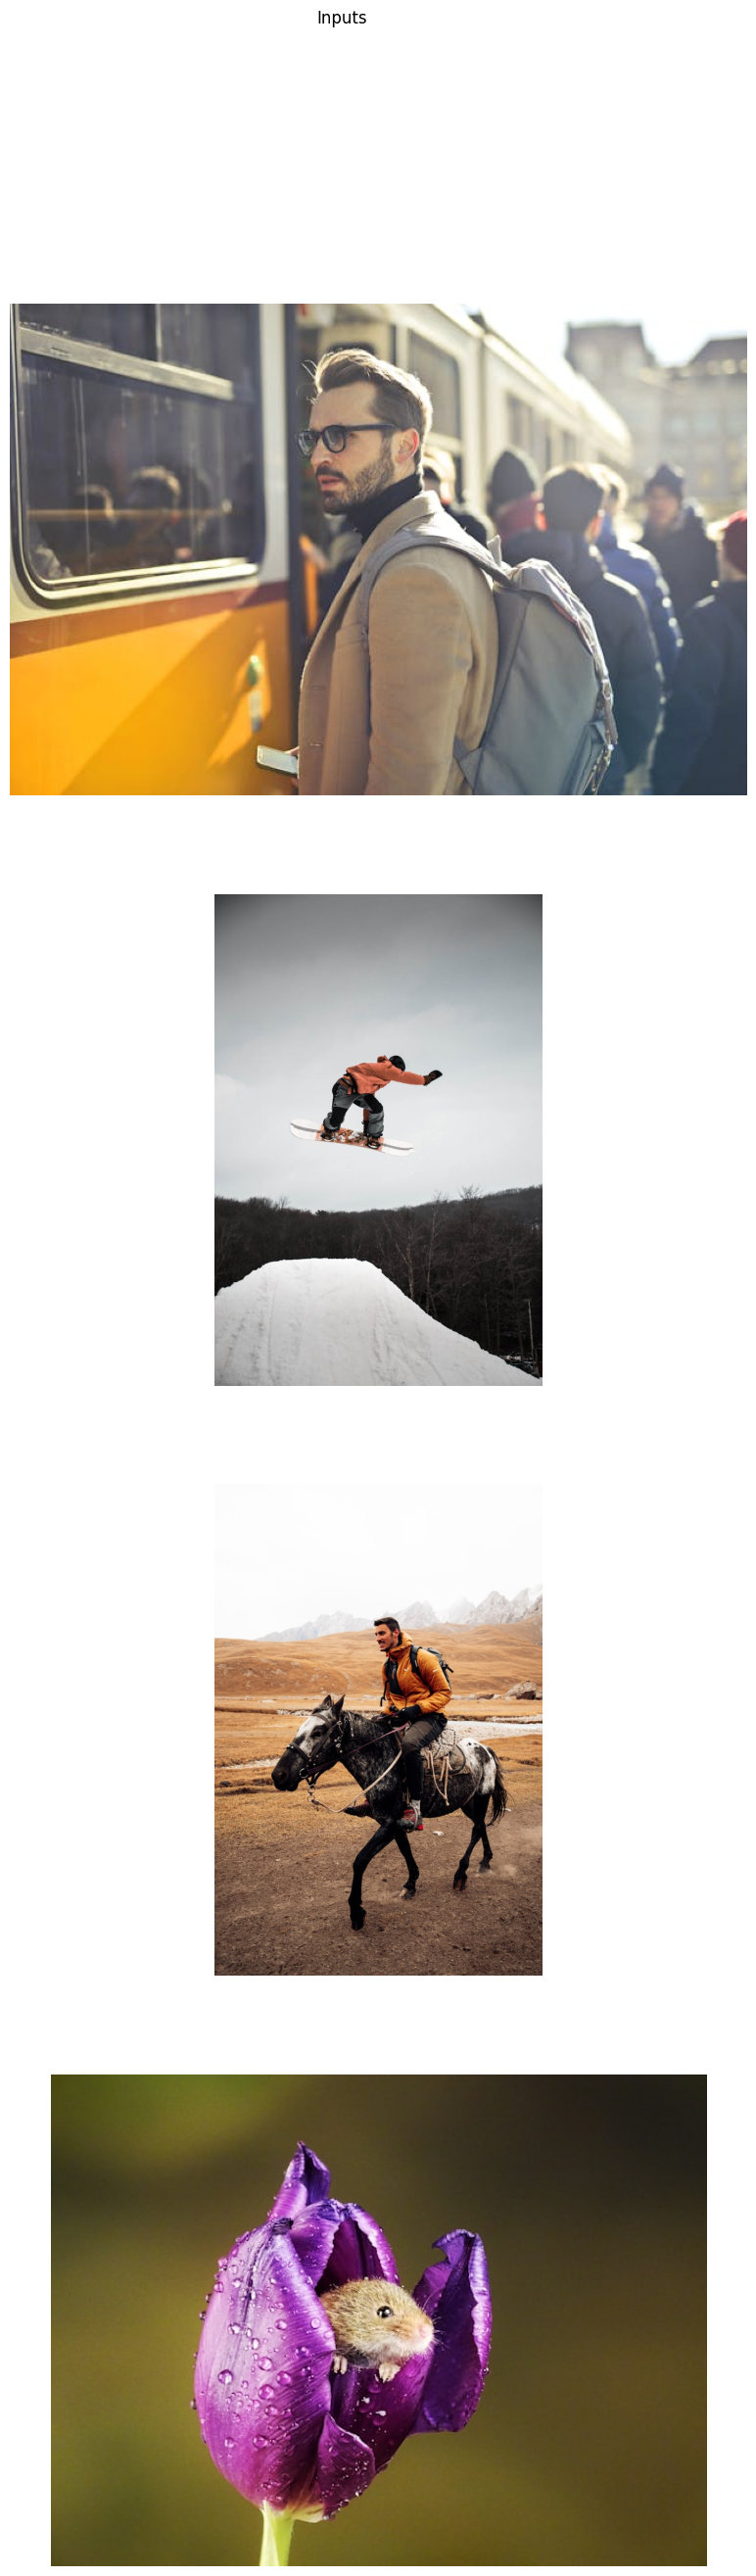

In [19]:
DATA_ROOT = PARENT / "input"
input_paths = sorted(DATA_ROOT.rglob("*.jpg"))

inputLen = len(input_paths)
plt.figure(figsize=(30, 30))

for i in range(inputLen):
    img = Image.open(input_paths[i]).convert("RGB")
    plt.subplot(inputLen, 1, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Inputs")
# img = Image.open(input_paths[0]).convert("RGB")
# plt.imshow(img)
plt.show()

## Inference with Points

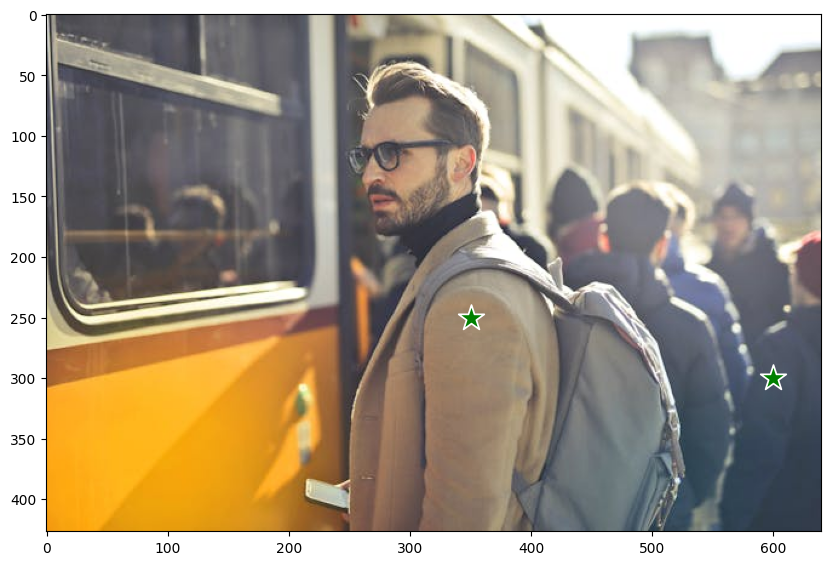

In [20]:
input_points = [[[350, 250], [600, 300]]]

img = Image.open(input_paths[0]).convert("RGB")
show_points_on_image(img, input_points[0])

In [21]:
inputs = processor(img, input_points=input_points, return_tensors="tf")
outputs = model(**inputs)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


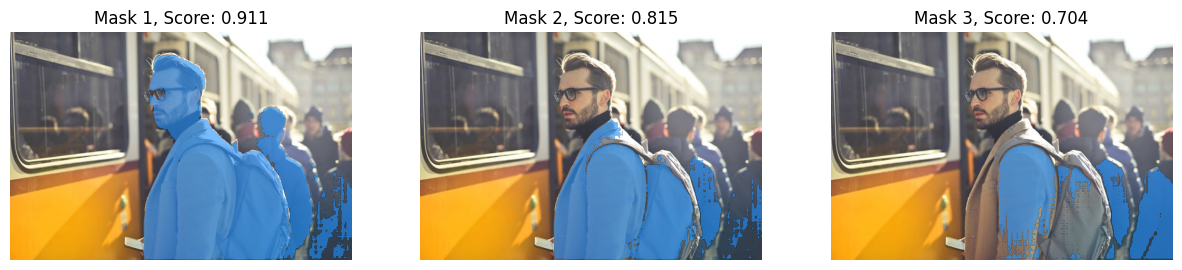

In [22]:
masks = processor.image_processor.post_process_masks(
    outputs.pred_masks,
    inputs["original_sizes"],
    inputs["reshaped_input_sizes"],
    return_tensors="tf",
)

show_masks_on_image(img, masks, outputs.iou_scores)